Successfully loaded dataset.

--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Cleaned Data Preview ---
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Sex_bool
0         0       3    male  22.0      1      0   7.2500        S         0
1     

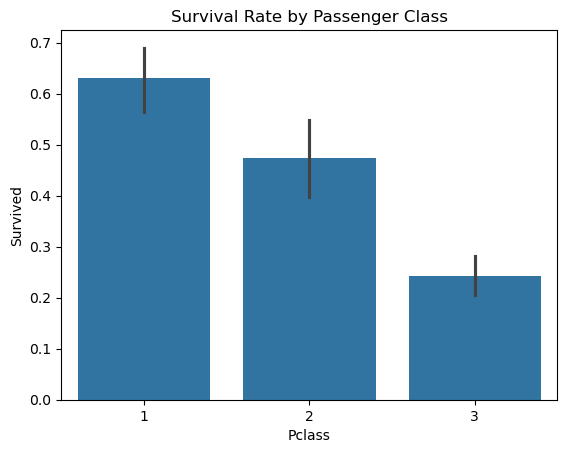

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def clean_titanic_data(file_path):
    # 1. Load the dataset
    try:
        df = pd.read_csv(file_path)
        print("Successfully loaded dataset.")
    except FileNotFoundError:
        print("Error: The file 'Titanic.csv' was not found.")
        return None

    # 2. Initial Data Inspection
    print("\n--- Initial Info ---")
    print(df.info())

    # 3. Handling Missing Values
    # Fill missing Age with the median
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # Fill missing Embarked with the most common value (mode)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode())

    # Drop Cabin if it has too many missing values (often >70% missing)
    if 'Cabin' in df.columns:
        df.drop(columns=['Cabin'], inplace=True)

    # 4. Data Transformation
    # Convert Sex to numeric for analysis (0 for male, 1 for female)
    df['Sex_bool'] = df['Sex'].map({'male': 0, 'female': 1})

    # 5. Drop Unnecessary Columns for Analysis
    cols_to_drop = ['PassengerId', 'Name', 'Ticket']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

    return df

# --- Execute Analysis ---
file_name = 'Titanic.csv'  # Ensure this file is in your project folder
titanic_df = clean_titanic_data(file_name)

if titanic_df is not None:
    print("\n--- Cleaned Data Preview ---")
    print(titanic_df.head())
    
    # Quick Visualization: Survival Rate by Class
    sns.barplot(x='Pclass', y='Survived', data=titanic_df)
    plt.title('Survival Rate by Passenger Class')
    plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17080\1597891655.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


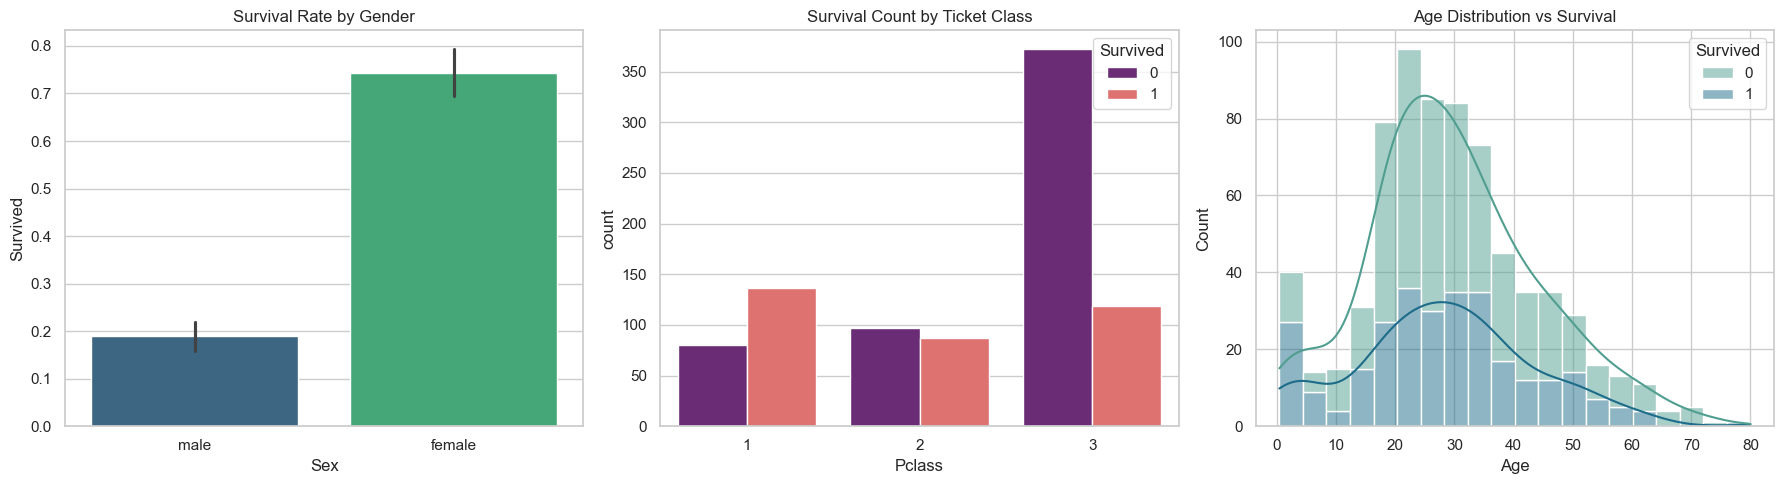

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (assuming it's already cleaned from the previous step)
df = pd.read_csv('Titanic.csv')

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# --- Visualization 1: Survival by Gender ---
plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender')

# --- Visualization 2: Survival by Passenger Class ---
plt.subplot(1, 3, 2)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Ticket Class')

# --- Visualization 3: Age Distribution of Survivors ---
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', kde=True, palette='crest')
plt.title('Age Distribution vs Survival')

plt.tight_layout()
plt.show()